# Homework 13

## Импорты, seed и среда

In [30]:

# Базовые библиотеки для воспроизводимости, анализа и удобного отображения результатов.
import random
from typing import Iterable

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    DataCollatorWithPadding
)
from datasets import load_dataset
from collections import Counter
import os
import json
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

print(f"Device: {device}")

Device: mps


In [3]:
# Берём стандартную мультиязычную BERT-модель: она хорошо подходит для русскоязычных примеров.
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

Tokenizer loaded: bert-base-uncased
Tokenizer class: BertTokenizer
Model max length: 512


## Датасет и первичный анализ

In [4]:
dataset = load_dataset("dair-ai/emotion")

In [5]:
for split_name, split_data in dataset.items():
    print(f"{split_name:12s}: {len(split_data):>6} примеров")

train       :  16000 примеров
validation  :   2000 примеров
test        :   2000 примеров


In [6]:
label_names = dataset["train"].features["label"].names
print("Классы:", label_names)

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [7]:
train_labels = dataset["train"]["label"]
counts = Counter(train_labels)
print("\nРаспределение классов (train):")
for idx, count in sorted(counts.items()):
    print(f"  {label_names[idx]:10s}: {count:>5} ({count/len(train_labels)*100:.1f}%)")


Распределение классов (train):
  sadness   :  4666 (29.2%)
  joy       :  5362 (33.5%)
  love      :  1304 (8.2%)
  anger     :  2159 (13.5%)
  fear      :  1937 (12.1%)
  surprise  :   572 (3.6%)


In [8]:
print("\n 5 примеров из train ")
for i in range(5):
    ex = dataset["train"][i]
    print(f"  [{label_names[ex['label']]:8s}] {ex['text'][:80]}")

print("\n 3 примера из validation ")
for i in range(3):
    ex = dataset["validation"][i]
    print(f"  [{label_names[ex['label']]:8s}] {ex['text'][:80]}")


 5 примеров из train 
  [sadness ] i didnt feel humiliated
  [sadness ] i can go from feeling so hopeless to so damned hopeful just from being around so
  [anger   ] im grabbing a minute to post i feel greedy wrong
  [love    ] i am ever feeling nostalgic about the fireplace i will know that it is still on 
  [anger   ] i am feeling grouchy

 3 примера из validation 
  [sadness ] im feeling quite sad and sorry for myself but ill snap out of it soon
  [sadness ] i feel like i am still looking at a blank canvas blank pieces of paper
  [love    ] i feel like a faithful servant


В датасете классифицируется эмоциональная окраска твита, насторение автора.

## Токенизация

In [9]:
example_text = dataset['train'][1]['text']

In [10]:
encoding = tokenizer(
    example_text,
    add_special_tokens=True,
    return_attention_mask=True,
    return_special_tokens_mask=True,  
)

print("Исходный текст:")
print(example_text)
print()

print("Токены (с спец-токенами):")
print(tokenizer.convert_ids_to_tokens(encoding["input_ids"]))
print()

print("input_ids:")
print(encoding["input_ids"])
print()

print("attention_mask:")
print(encoding["attention_mask"])
print()

print("special_tokens_mask (1 = спец-токен):")
print(encoding["special_tokens_mask"])

Исходный текст:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены (с спец-токенами):
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']

input_ids:
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

attention_mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

special_tokens_mask (1 = спец-токен):
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [11]:
def inspect_single_text(text: str, tokenizer) -> pd.DataFrame:
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_special_tokens_mask=True,
    )
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    return pd.DataFrame({
        "position":            list(range(len(tokens))),
        "token":               tokens,
        "token_id":            encoding["input_ids"],
        "attention_mask":      encoding["attention_mask"],
        "is_special_token":    encoding["special_tokens_mask"],
    })

for i in range(3):
    ex = dataset['train'][i]
    label_str = dataset['train'].features['label'].names[ex['label']]
    print(f"\n[{label_str}] {ex['text']}")
    df = inspect_single_text(ex['text'], tokenizer)
    display(df)


[sadness] i didnt feel humiliated


,position,token,token_id,attention_mask,is_special_token
0,0,[CLS],101,1,1
1,1,i,1045,1,0
2,2,didn,2134,1,0
3,3,##t,2102,1,0
4,4,feel,2514,1,0
5,5,humiliated,26608,1,0
6,6,[SEP],102,1,1



[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


,position,token,token_id,attention_mask,is_special_token
0,0,[CLS],101,1,1
1,1,i,1045,1,0
2,2,can,2064,1,0
3,3,go,2175,1,0
4,4,from,2013,1,0
5,5,feeling,3110,1,0
6,6,so,2061,1,0
7,7,hopeless,20625,1,0
8,8,to,2000,1,0
9,9,so,2061,1,0



[anger] im grabbing a minute to post i feel greedy wrong


,position,token,token_id,attention_mask,is_special_token
0,0,[CLS],101,1,1
1,1,im,10047,1,0
2,2,grabbing,9775,1,0
3,3,a,1037,1,0
4,4,minute,3371,1,0
5,5,to,2000,1,0
6,6,post,2695,1,0
7,7,i,1045,1,0
8,8,feel,2514,1,0
9,9,greedy,20505,1,0


In [12]:
short_text  = "I feel happy"
medium_text = dataset['train'][0]['text']
long_text   = " ".join(["word"] * 100)  # искусственно длинный текст

texts = [short_text, medium_text, long_text]

batch_padded = tokenizer(
    texts,
    padding="longest",       # все выравниваются до самого длинного
    truncation=False,
    return_tensors="pt",
)
print("=== padding='longest', truncation=False ===")
print("input_ids shape:", batch_padded["input_ids"].shape)
for i, text in enumerate(texts):
    ids   = batch_padded["input_ids"][i].tolist()
    mask  = batch_padded["attention_mask"][i].tolist()
    n_pad = mask.count(0)
    print(f"  Текст {i+1}: длина={len(ids)}, PAD-токенов={n_pad}")

print()

batch_trunc = tokenizer(
    texts,
    padding="max_length",    # паддинг до max_length
    truncation=True,         # обрезаем всё длиннее max_length
    max_length=16,
    return_tensors="pt",
)
print("=== padding='max_length', truncation=True, max_length=16 ===")
print("input_ids shape:", batch_trunc["input_ids"].shape)
for i, text in enumerate(texts):
    ids  = batch_trunc["input_ids"][i].tolist()
    mask = batch_trunc["attention_mask"][i].tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    print(f"  Текст {i+1}: {toks}")
    print(f"           mask: {mask}")
    print()

=== padding='longest', truncation=False ===
input_ids shape: torch.Size([3, 102])
  Текст 1: длина=102, PAD-токенов=97
  Текст 2: длина=102, PAD-токенов=95
  Текст 3: длина=102, PAD-токенов=0

=== padding='max_length', truncation=True, max_length=16 ===
input_ids shape: torch.Size([3, 16])
  Текст 1: ['[CLS]', 'i', 'feel', 'happy', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
           mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  Текст 2: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
           mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  Текст 3: ['[CLS]', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', '[SEP]']
           mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]



In [13]:
print("Special tokens:")
print(f"  [CLS] token : '{tokenizer.cls_token}'  id={tokenizer.cls_token_id}")
print(f"  [SEP] token : '{tokenizer.sep_token}'  id={tokenizer.sep_token_id}")
print(f"  [PAD] token : '{tokenizer.pad_token}'  id={tokenizer.pad_token_id}")
print(f"  [UNK] token : '{tokenizer.unk_token}'  id={tokenizer.unk_token_id}")
print(f"  [MASK] token: '{tokenizer.mask_token}' id={tokenizer.mask_token_id}")
print()

# Покажем, как CLS и SEP оборачивают текст
text = "I feel great today"
tokens_no_special = tokenizer.tokenize(text)
tokens_with_special = tokenizer.convert_ids_to_tokens(
    tokenizer.encode(text, add_special_tokens=True)
)
print(f"Без спец-токенов : {tokens_no_special}")
print(f"Со спец-токенами : {tokens_with_special}")
#  --> ['[CLS]', 'i', 'feel', 'great', 'today', '[SEP]']

Special tokens:
  [CLS] token : '[CLS]'  id=101
  [SEP] token : '[SEP]'  id=102
  [PAD] token : '[PAD]'  id=0
  [UNK] token : '[UNK]'  id=100
  [MASK] token: '[MASK]' id=103

Без спец-токенов : ['i', 'feel', 'great', 'today']
Со спец-токенами : ['[CLS]', 'i', 'feel', 'great', 'today', '[SEP]']


## Инференс готовой модели

In [14]:
classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=False,   
    device=device 
)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 38587.74it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
print(f"Классы нашего датасета : {label_names}")
print(f"Классы pretrained модели: anger, disgust, fear, joy, neutral, sadness, surprise")
print()

# Берём 5 примеров из test-части датасета
test_examples = dataset["test"].select(range(5))

print(f"{'Текст (обрезан до 60 символов)':<62} {'Истина':<10} {'Предсказание':<12} {'Score'}")
print("-" * 100)

for ex in test_examples:
    text        = ex["text"]
    true_label  = label_names[ex["label"]]
    result      = classifier(text)[0]
    pred_label  = result["label"]
    score       = result["score"]
    match       = "✅" if pred_label == true_label else "❌"
    print(f"{text[:60]:<62} {true_label:<10} {pred_label:<12} {score:.2f}  {match}")

Классы нашего датасета : ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Классы pretrained модели: anger, disgust, fear, joy, neutral, sadness, surprise

Текст (обрезан до 60 символов)                                 Истина     Предсказание Score
----------------------------------------------------------------------------------------------------
im feeling rather rotten so im not very ambitious right now    sadness    sadness      0.99  ✅
im updating my blog because i feel shitty                      sadness    sadness      0.99  ✅
i never make her separate from me because i don t ever want    sadness    sadness      0.98  ✅
i left with my bouquet of red and yellow tulips under my arm   joy        joy          0.99  ✅
i was feeling a little vain when i did this one                sadness    sadness      0.99  ✅


In [16]:
print("\n" + "=" * 70)
print("ПОДРОБНЫЙ РАЗБОР 5 ПРИМЕРОВ")
print("=" * 70)

classifier_full = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    device=device
)

for i, ex in enumerate(test_examples):
    text       = ex["text"]
    true_label = label_names[ex["label"]]
    
    # top_k=None → pipeline возвращает [[{...}, {...}, ...]]
    # [0] берёт результат для первого (единственного) текста
    all_scores = classifier_full(text)[0]  # список словарей

    print(f"\nПример {i+1}:")
    print(f"  Текст         : {text}")
    print(f"  Истинная метка: {true_label}")
    print(f"  Предсказания  :")
    for item in sorted(all_scores, key=lambda x: x["score"], reverse=True):
        bar = "█" * int(item["score"] * 20)
        print(f"    {item['label']:10s}: {item['score']:.3f}  {bar}")


ПОДРОБНЫЙ РАЗБОР 5 ПРИМЕРОВ


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 35035.95it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Пример 1:
  Текст         : im feeling rather rotten so im not very ambitious right now
  Истинная метка: sadness
  Предсказания  :
    sadness   : 0.992  ███████████████████
    anger     : 0.003  
    joy       : 0.003  
    surprise  : 0.001  
    disgust   : 0.001  
    fear      : 0.001  
    neutral   : 0.000  

Пример 2:
  Текст         : im updating my blog because i feel shitty
  Истинная метка: sadness
  Предсказания  :
    sadness   : 0.993  ███████████████████
    anger     : 0.001  
    disgust   : 0.001  
    neutral   : 0.001  
    fear      : 0.001  
    surprise  : 0.001  
    joy       : 0.001  

Пример 3:
  Текст         : i never make her separate from me because i don t ever want her to feel like i m ashamed with her
  Истинная метка: sadness
  Предсказания  :
    sadness   : 0.982  ███████████████████
    neutral   : 0.005  
    disgust   : 0.005  
    surprise  : 0.003  
    fear      : 0.002  
    joy       : 0.002  
    anger     : 0.001  

Пример 4:
  Текст  

In [17]:
print("\n" + "=" * 70)
print("АНАЛИЗ ПРИГОДНОСТИ PRETRAINED МОДЕЛИ")
print("=" * 70)

our_classes     = set(label_names)
model_classes   = {"anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"}

only_in_ours    = our_classes - model_classes
only_in_model   = model_classes - our_classes
overlap         = our_classes & model_classes

print(f"Наши классы    : {sorted(our_classes)}")
print(f"Классы модели  : {sorted(model_classes)}")
print(f"Совпадают      : {sorted(overlap)}   ({len(overlap)}/{len(our_classes)})")
print(f"Только у нас   : {only_in_ours}   ← модель их не предсказывает!")
print(f"Только в модели: {only_in_model}  ← лишние классы")


АНАЛИЗ ПРИГОДНОСТИ PRETRAINED МОДЕЛИ
Наши классы    : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Классы модели  : ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Совпадают      : ['anger', 'fear', 'joy', 'sadness', 'surprise']   (5/6)
Только у нас   : {'love'}   ← модель их не предсказывает!
Только в модели: {'disgust', 'neutral'}  ← лишние классы


## Fine-tuning для классификации текста

In [ ]:
MAX_LENGTH   = 128
BATCH_SIZE   = 32
NUM_EPOCHS   = 2
LR           = 2e-5

In [19]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        # padding делается динамически через DataCollatorWithPadding
    )

tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
tokenized.set_format("torch")

In [20]:
from sklearn.metrics import accuracy_score, f1_score

label_names = dataset["train"].features["label"].names
num_labels  = len(label_names)
# Загружаем модель с классификационной головой
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11995.95it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

In [23]:
training_args = TrainingArguments(
    output_dir           = "./checkpoints",
    num_train_epochs     = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate        = LR,
    weight_decay         = 0.01,
    warmup_ratio         = 0.1,           # 10% шагов — разогрев LR

    # ── Ключевое: выбор лучшей модели по validation ────
    eval_strategy        = "epoch",       # оцениваем после каждой эпохи
    save_strategy        = "epoch",       # сохраняем чекпойнт после каждой эпохи
    metric_for_best_model= "f1_macro",    # критерий выбора лучшего чекпойнта
    greater_is_better    = True,
    load_best_model_at_end = True,        # в конце загрузить лучший чекпойнт

    save_total_limit     = 2,             # хранить не более 2 чекпойнтов
    logging_steps        = 50,
    seed                 = 42,
    report_to            = "none",        # отключаем wandb/tensorboard
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized["train"],
    eval_dataset    = tokenized["validation"],
    processing_class = tokenizer,
    data_collator   = DataCollatorWithPadding(tokenizer),  # динамический padding
    compute_metrics = compute_metrics,
)

# ── Обучение ───────────────────────────────────────────────
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.246076,0.234968,0.916000,0.892668
2,0.127705,0.156052,0.933500,0.907749
3,0.097540,0.145999,0.937500,0.913177


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s]
/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.33it/s]
/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.53it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.e

TrainOutput(global_step=1500, training_loss=0.3397339859008789, metrics={'train_runtime': 873.7374, 'train_samples_per_second': 54.936, 'train_steps_per_second': 1.717, 'total_flos': 1286642823596928.0, 'train_loss': 0.3397339859008789, 'epoch': 3.0})

## Оценка качества

In [25]:
test_results = trainer.evaluate(tokenized["test"])

print("\n" + "=" * 45)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET")
print("=" * 45)
print(f"  Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"  F1 macro : {test_results['eval_f1_macro']:.4f}")

/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


RuntimeError: on_train_begin must be called before on_evaluate

/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


МЕТРИКИ НА TEST SET
  Accuracy  : 0.9235
  F1 macro  : 0.8767
  F1 weighted: 0.9230

              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.94      0.95      0.95       695
        love       0.84      0.79      0.82       159
       anger       0.93      0.90      0.92       275
        fear       0.86      0.92      0.89       224
    surprise       0.77      0.70      0.73        66

    accuracy                           0.92      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000



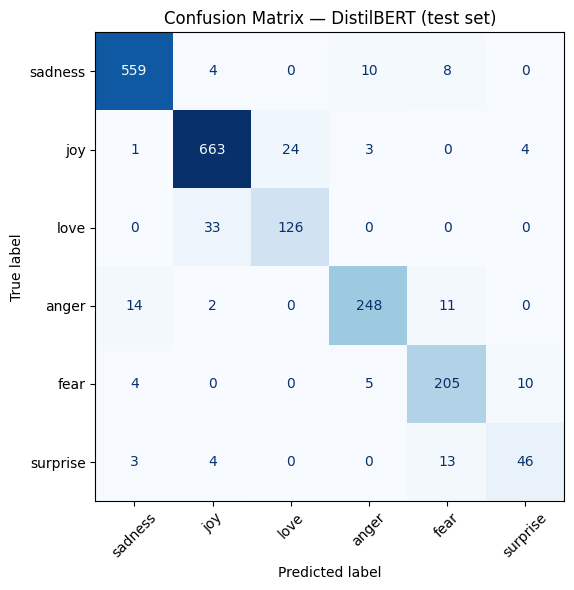

In [26]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# ── Получаем предсказания на test ──────────────────────────
preds_output = trainer.predict(tokenized["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# ── Accuracy и F1 ──────────────────────────────────────────
print("=" * 55)
print("МЕТРИКИ НА TEST SET")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"  F1 macro  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"  F1 weighted: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=label_names))

# ── Матрица ошибок ─────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix — DistilBERT (test set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [27]:
# ── 10 примеров: правильные и ошибочные ────────────────────
test_texts = dataset["test"]["text"]

results_df = pd.DataFrame({
    "text"      : test_texts,
    "true_label": [label_names[i] for i in y_true],
    "pred_label": [label_names[i] for i in y_pred],
    "correct"   : y_true == y_pred,
})

# Добавляем вероятности топ-предсказания
probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
results_df["confidence"] = probs.max(axis=-1)

print("\n=== 5 ПРАВИЛЬНЫХ предсказаний (высокая уверенность) ===")
correct = results_df[results_df["correct"]].nlargest(5, "confidence")
for _, row in correct.iterrows():
    print(f"  [{row['true_label']:8s}→{row['pred_label']:8s}] conf={row['confidence']:.2f}  {row['text'][:70]}")

print("\n=== 5 ОШИБОЧНЫХ предсказаний ===")
errors = results_df[~results_df["correct"]].sample(5, random_state=42)
for _, row in errors.iterrows():
    print(f"  [true={row['true_label']:8s} pred={row['pred_label']:8s}] conf={row['confidence']:.2f}  {row['text'][:70]}")


=== 5 ПРАВИЛЬНЫХ предсказаний (высокая уверенность) ===
  [sadness →sadness ] conf=1.00  i lay here typing this hate blog entry that no one would read although
  [sadness →sadness ] conf=1.00  i felt abandoned for what seemed like the millionth time in my life an
  [sadness →sadness ] conf=1.00  i feel pathetic that i can hardly go a whole day not talking to him
  [sadness →sadness ] conf=1.00  i mean i feel like a broke record sometimes
  [sadness →sadness ] conf=1.00  i feel like damaged goods no one will want me now

=== 5 ОШИБОЧНЫХ предсказаний ===
  [true=surprise pred=fear    ] conf=0.64  i feel shame in a strange way
  [true=sadness  pred=anger   ] conf=0.52  i reread for comfort the familiarity of a book whose plot i already kn
  [true=joy      pred=sadness ] conf=0.95  i feel very saddened that the king whom i once quite respected as far 
  [true=joy      pred=love    ] conf=0.82  i like the fresh feeling of sweet he gave me
  [true=anger    pred=sadness ] conf=0.55  i have b

## Сохранение артефактов

In [31]:


# ══════════════════════════════════════════════════════════
# 1. sample_predictions.csv
# ══════════════════════════════════════════════════════════
# Берём 10 ошибочных + 10 правильных для баланса
errors  = results_df[~results_df["correct"]].sample(
    min(10, (~results_df["correct"]).sum()), random_state=42
)
correct = results_df[results_df["correct"]].sample(
    min(10, results_df["correct"].sum()), random_state=42
)

sample_df = (
    pd.concat([errors, correct])
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
    [["text", "true_label", "pred_label", "confidence", "correct"]]
)

sample_path = f"{ARTIFACTS_DIR}/sample_predictions.csv"
sample_df.to_csv(sample_path, index=False)
print(f"✅ {sample_path}  ({len(sample_df)} строк)")
print(sample_df[["true_label", "pred_label", "confidence", "correct"]].to_string())

✅ artifacts/sample_predictions.csv  (20 строк)
   true_label pred_label  confidence  correct
0     sadness    sadness    0.997601     True
1         joy        joy    0.997471     True
2         joy        joy    0.997414     True
3         joy        joy    0.997367     True
4         joy        joy    0.996916     True
5         joy        joy    0.996268     True
6        fear       fear    0.994517     True
7       anger      anger    0.994268     True
8         joy    sadness    0.950828    False
9       anger    sadness    0.909342    False
10        joy       love    0.820948    False
11    sadness    sadness    0.801301     True
12       love       love    0.706109     True
13   surprise       fear    0.693834    False
14   surprise       fear    0.637274    False
15       love        joy    0.608783    False
16       love        joy    0.608694    False
17      anger    sadness    0.549089    False
18    sadness       fear    0.540110    False
19    sadness      anger    0.519

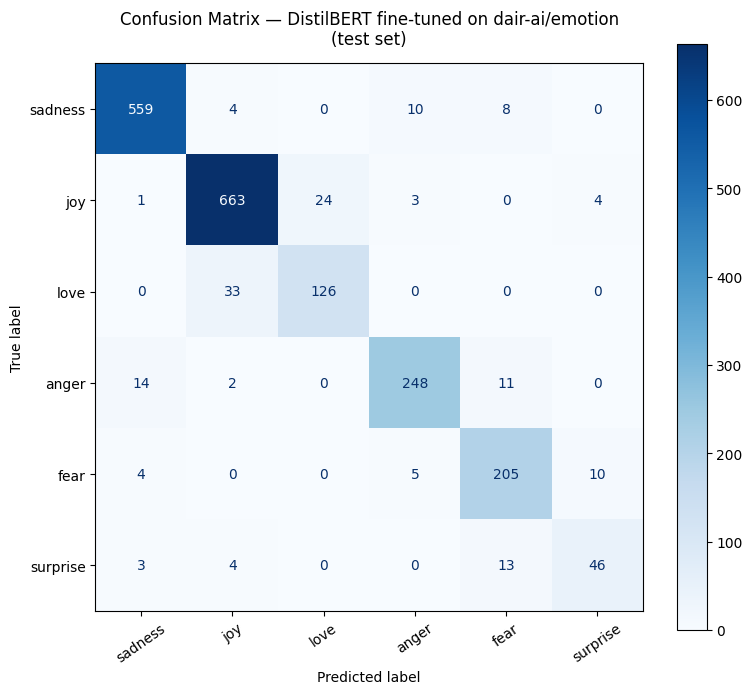

✅ artifacts/confusion_matrix.png


In [32]:
# ══════════════════════════════════════════════════════════
# 2. confusion_matrix.png
# ══════════════════════════════════════════════════════════
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    xticks_rotation=35,
)
ax.set_title(
    "Confusion Matrix — DistilBERT fine-tuned on dair-ai/emotion\n(test set)",
    fontsize=12, pad=14
)
plt.tight_layout()
cm_path = f"{ARTIFACTS_DIR}/confusion_matrix.png"
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ {cm_path}")

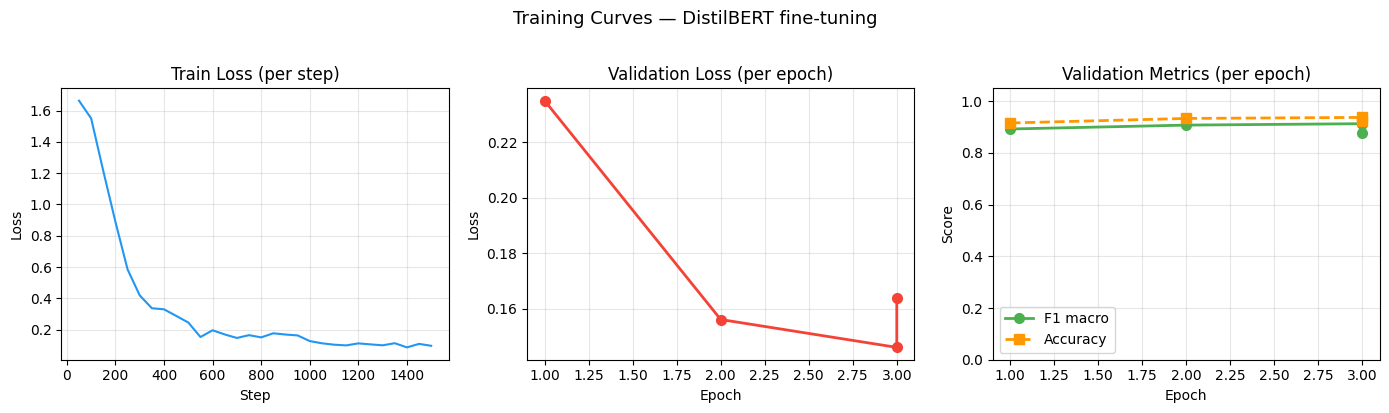

✅ artifacts/training_curves.png


In [33]:
# ══════════════════════════════════════════════════════════
# 3. training_curves.png  (loss + f1_macro по эпохам)
# ══════════════════════════════════════════════════════════
log_history = trainer.state.log_history

# Разделяем train-loss и eval-метрики
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_steps  = [x["step"]  for x in train_logs]
train_losses = [x["loss"]  for x in train_logs]

eval_epochs  = [x["epoch"]     for x in eval_logs]
eval_losses  = [x["eval_loss"] for x in eval_logs]
eval_f1      = [x.get("eval_f1_macro", None) for x in eval_logs]
eval_acc     = [x.get("eval_accuracy", None)  for x in eval_logs]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Train loss (по шагам)
axes[0].plot(train_steps, train_losses, color="#2196F3", linewidth=1.5)
axes[0].set_title("Train Loss (per step)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Eval loss (по эпохам)
axes[1].plot(eval_epochs, eval_losses, "o-", color="#F44336", linewidth=2, markersize=7)
axes[1].set_title("Validation Loss (per epoch)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

# F1 + Accuracy на validation
if any(v is not None for v in eval_f1):
    axes[2].plot(eval_epochs, eval_f1,  "o-", color="#4CAF50",
                 linewidth=2, markersize=7, label="F1 macro")
if any(v is not None for v in eval_acc):
    axes[2].plot(eval_epochs, eval_acc, "s--", color="#FF9800",
                 linewidth=2, markersize=7, label="Accuracy")
axes[2].set_title("Validation Metrics (per epoch)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Training Curves — DistilBERT fine-tuning", fontsize=13, y=1.02)
plt.tight_layout()
curves_path = f"{ARTIFACTS_DIR}/training_curves.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ {curves_path}")

In [34]:
# ══════════════════════════════════════════════════════════
# 4. tokenization_examples.txt
# ══════════════════════════════════════════════════════════
MAX_LENGTH = 128
examples = dataset["train"].select(range(5))
lines = []
lines.append("=" * 65)
lines.append("TOKENIZATION EXAMPLES — distilbert-base-uncased")
lines.append(f"max_length={MAX_LENGTH}, add_special_tokens=True")
lines.append("=" * 65)

for i, ex in enumerate(examples):
    text       = ex["text"]
    true_label = label_names[ex["label"]]
    enc = tokenizer(text, add_special_tokens=True,
                    truncation=True, max_length=MAX_LENGTH,
                    return_special_tokens_mask=True)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])

    lines.append(f"\n[Example {i+1}] label={true_label}")
    lines.append(f"  text            : {text}")
    lines.append(f"  tokens          : {tokens}")
    lines.append(f"  input_ids       : {enc['input_ids']}")
    lines.append(f"  attention_mask  : {enc['attention_mask']}")
    lines.append(f"  special_tok_mask: {enc['special_tokens_mask']}")
    lines.append(f"  seq_length      : {len(enc['input_ids'])}")

# Padding / truncation демо
lines.append("\n" + "=" * 65)
lines.append("PADDING & TRUNCATION DEMO")
lines.append("=" * 65)
short_text  = "I feel happy"
long_text   = " ".join(["word"] * 100)
batch = tokenizer(
    [short_text, long_text],
    padding="max_length", truncation=True, max_length=16
)
for j, (txt, ids, mask) in enumerate(
    zip([short_text, long_text],
        batch["input_ids"], batch["attention_mask"])
):
    toks = tokenizer.convert_ids_to_tokens(ids)
    lines.append(f"\n  text  : {txt[:50]}")
    lines.append(f"  tokens: {toks}")
    lines.append(f"  mask  : {mask}")

tok_path = f"{ARTIFACTS_DIR}/tokenization_examples.txt"
with open(tok_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"✅ {tok_path}")

✅ artifacts/tokenization_examples.txt


In [35]:
print("\n📁 Содержимое artifacts/:")
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    size = os.path.getsize(f"{ARTIFACTS_DIR}/{fname}")
    print(f"   {fname:<35} {size:>8,} байт")


📁 Содержимое artifacts/:
   confusion_matrix.png                  67,766 байт
   sample_predictions.csv                 2,753 байт
   tokenization_examples.txt              3,384 байт
   training_curves.png                   82,707 байт
